# Préparation des features — Maintenance prédictive (Gold Dataset)

**Contexte technique** : Python, pandas, pyarrow, scikit-learn. Installation des packages via `uv`.

**Fichier source** : `artifacts/ingestions/datas/gold_dataset.parquet`

Étapes :
1. Charger le parquet, trié par machine puis par temps
2. Exclure les colonnes de fuite, les identifiants et les labels des features
3. Choisir un horizon et construire la cible `y` (0/1)
4. Utiliser le split temporel fourni (`split_set` : train < validation < test)
5. Imputer les NaN (médiane) ; standardiser pour les modèles linéaires


In [1]:
# Installation des dépendances (si nécessaire)
# uv add ipykernel pandas jupyter xgboost   
# uv add pyarrow scikit-learn xgboost matplotlib seaborn

In [2]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 100)


## 1) Charger le parquet, trié par machine puis par temps

In [3]:
DATA_PATH = "artifacts/ingestions/datas/gold_dataset.parquet"

df = pd.read_parquet(DATA_PATH)
df = df.sort_values(["machine_id_std", "window_start"]).reset_index(drop=True)

print(df.shape)
df.head()


(134280, 100)


,machine_id_std,window_start,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,pieces_produced_sum_1h,window_end,temp_mean_6h,temp_max_6h,temp_std_6h,pressure_mean_6h,pressure_max_6h,pressure_std_6h,voltage_mean_6h,voltage_max_6h,voltage_std_6h,rotation_mean_6h,rotation_max_6h,rotation_std_6h,temp_mean_12h,temp_max_12h,temp_std_12h,pressure_mean_12h,pressure_max_12h,pressure_std_12h,voltage_mean_12h,voltage_max_12h,voltage_std_12h,rotation_mean_12h,rotation_max_12h,rotation_std_12h,temp_mean_24h,temp_max_24h,temp_std_24h,pressure_mean_24h,pressure_max_24h,pressure_std_24h,voltage_mean_24h,voltage_max_24h,voltage_std_24h,rotation_mean_24h,rotation_max_24h,rotation_std_24h,temp_trend_6h,pressure_trend_6h,voltage_trend_6h,rotation_trend_6h,temp_zscore_24h,temp_delta_1h,temp_delta_3h,pressure_delta_1h,pressure_delta_3h,rotation_delta_1h,rotation_delta_3h,voltage_delta_1h,voltage_delta_3h,temp_zscore_machine,pressure_zscore_machine,pieces_produced_sum_24h,capacity_utilization_pct,incident_count_1h,incident_max_severity_1h,incident_count_prev_24h,incident_max_severity_prev_24h,incident_count_prev_7d,hours_since_last_incident,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite,type_surchauffe_count_prev_24h,type_baisse_pression_count_prev_24h,type_vibration_count_prev_24h,type_bruit_mecanique_count_prev_24h,type_surconsommation_count_prev_24h,type_blocage_mecanique_count_prev_24h,type_alarme_capteur_count_prev_24h,type_arret_urgence_count_prev_24h,type_defaut_qualite_count_prev_24h,days_since_last_maintenance,maintenance_count_prev_30d,future_incident_count_6h,label_failure_next_6h,future_incident_count_12h,label_failure_next_12h,future_incident_count_24h,label_failure_next_24h,future_incident_count_48h,label_failure_next_48h,split_set
0,MACH-01,2025-06-01 00:00:00,46.340,46.340,198.203,198.203,227.568,227.568,1541.787,1541.787,4,2025-06-01 01:00:00,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.921634,-0.642904,4,0.347222,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
1,MACH-01,2025-06-01 01:00:00,48.762,48.762,198.295,198.295,227.480,227.480,1537.860,1537.860,4,2025-06-01 02:00:00,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,NaN,NaN,NaN,NaN,0.707107,2.422,NaN,0.092,NaN,-3.927,NaN,-0.088,NaN,-0.340840,-0.598766,8,0.694444,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
2,MACH-01,2025-06-01 02:00:00,51.352,51.352,199.545,199.545,228.680,228.680,1584.660,1584.660,13,2025-06-01 03:00:00,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,NaN,NaN,NaN,NaN,1.010984,2.590,NaN,1.250,NaN,46.800,NaN,1.200,NaN,0.280242,0.000936,21,1.822917,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
3,MACH-01,2025-06-01 03:00:00,49.512,49.512,201.641,201.641,228.440,228.440,1588.960,1588.960,10,2025-06-01 04:00:00,48.9915,51.352,2.075733,199.4210,201.641,1.601580,228.042000

## 2) Exclure les colonnes de fuite, les identifiants et les labels des features

- **Identifiants / temporel** : `machine_id_std`, `window_start`, `window_end`
- **Fuite de données (leakage)** : `future_incident_count_6h/12h/24h/48h` — comptent des incidents futurs, utilisés pour construire les labels
- **Labels** : `label_failure_next_6h/12h/24h/48h`
- **Split** : `split_set`


In [4]:
id_cols = ["machine_id_std", "window_start", "window_end"]

leakage_cols = [
    "future_incident_count_6h",
    "future_incident_count_12h",
    "future_incident_count_24h",
    "future_incident_count_48h",
]

label_cols = [
    "label_failure_next_6h",
    "label_failure_next_12h",
    "label_failure_next_24h",
    "label_failure_next_48h",
]

control_cols = ["split_set"]

exclude_cols = id_cols + leakage_cols + label_cols + control_cols

feature_cols = [c for c in df.columns if c not in exclude_cols]

# Garde-fou : aucune colonne "future_*" ne doit rester dans les features
assert not any(c.startswith("future_") for c in feature_cols), "Fuite détectée dans les features !"

X_all = df[feature_cols]
print(f"{len(feature_cols)} features conservées")
X_all.head()


88 features conservées


,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,pieces_produced_sum_1h,temp_mean_6h,temp_max_6h,temp_std_6h,pressure_mean_6h,pressure_max_6h,pressure_std_6h,voltage_mean_6h,voltage_max_6h,voltage_std_6h,rotation_mean_6h,rotation_max_6h,rotation_std_6h,temp_mean_12h,temp_max_12h,temp_std_12h,pressure_mean_12h,pressure_max_12h,pressure_std_12h,voltage_mean_12h,voltage_max_12h,voltage_std_12h,rotation_mean_12h,rotation_max_12h,rotation_std_12h,temp_mean_24h,temp_max_24h,temp_std_24h,pressure_mean_24h,pressure_max_24h,pressure_std_24h,voltage_mean_24h,voltage_max_24h,voltage_std_24h,rotation_mean_24h,rotation_max_24h,rotation_std_24h,temp_trend_6h,pressure_trend_6h,voltage_trend_6h,rotation_trend_6h,temp_zscore_24h,temp_delta_1h,temp_delta_3h,pressure_delta_1h,pressure_delta_3h,rotation_delta_1h,rotation_delta_3h,voltage_delta_1h,voltage_delta_3h,temp_zscore_machine,pressure_zscore_machine,pieces_produced_sum_24h,capacity_utilization_pct,incident_count_1h,incident_max_severity_1h,incident_count_prev_24h,incident_max_severity_prev_24h,incident_count_prev_7d,hours_since_last_incident,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite,type_surchauffe_count_prev_24h,type_baisse_pression_count_prev_24h,type_vibration_count_prev_24h,type_bruit_mecanique_count_prev_24h,type_surconsommation_count_prev_24h,type_blocage_mecanique_count_prev_24h,type_alarme_capteur_count_prev_24h,type_arret_urgence_count_prev_24h,type_defaut_qualite_count_prev_24h,days_since_last_maintenance,maintenance_count_prev_30d
0,46.340,46.340,198.203,198.203,227.568,227.568,1541.787,1541.787,4,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.921634,-0.642904,4,0.347222,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0
1,48.762,48.762,198.295,198.295,227.480,227.480,1537.860,1537.860,4,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,NaN,NaN,NaN,NaN,0.707107,2.422,NaN,0.092,NaN,-3.927,NaN,-0.088,NaN,-0.340840,-0.598766,8,0.694444,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0
2,51.352,51.352,199.545,199.545,228.680,228.680,1584.660,1584.660,13,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,NaN,NaN,NaN,NaN,1.010984,2.590,NaN,1.250,NaN,46.800,NaN,1.200,NaN,0.280242,0.000936,21,1.822917,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0
3,49.512,49.512,201.641,201.641,228.440,228.440,1588.960,1588.960,10,48.9915,51.352,2.075733,199.4210,201.641,1.601580,228.042000,228.680,0.607170,1563.31675,1588.960,27.231641,48.9915,51.352,2.075733,199.4210,201.641,1.601580,228.042000,228.680,0.607170,1563.31675,1588.960,27.231641,48.9915,51.352,2.075733,199.4210,201.641,1.601580,228.042000,228.680,0.607170,1563.31675,1588.960,27.231641,NaN,NaN,NaN,NaN,0.250755,-1.840,3.172,2.096,3.438,4.300,47.173,-0.240,0.872,-0.160990,1.006515,31,2.690972,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0
4,51.982,51.982,200.157,200.157,227.840,227.840,1548.660,1548.660,6,49.5896,51.982,2.240562,199.5682,201.641,1.425529,228.001600,228.680

## 3) Choisir un horizon et construire la cible y (0/1)

Quatre horizons disponibles : `label_failure_next_6h`, `label_failure_next_12h`, `label_failure_next_24h`, `label_failure_next_48h`.


In [5]:
for col in label_cols:
    print(f"{col}: {df[col].mean():.1%} positifs")


label_failure_next_6h: 4.5% positifs
label_failure_next_12h: 8.8% positifs
label_failure_next_24h: 16.8% positifs
label_failure_next_48h: 25.5% positifs


In [6]:
HORIZON = "label_failure_next_24h"  # <-- changer ici pour un autre horizon

y = df[HORIZON].astype(int)
y.value_counts(normalize=True)


label_failure_next_24h
0    0.832082
1    0.167918
Name: proportion, dtype: float64

## 4) Utiliser le split temporel fourni (pas de split aléatoire)

⚠️ Ne jamais utiliser `train_test_split(shuffle=True)` : cela romprait la chronologie et provoquerait une fuite d'information.


In [7]:
print(df["split_set"].value_counts())
print((df["split_set"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

train_mask = df["split_set"] == "train"
val_mask   = df["split_set"] == "validation"
test_mask  = df["split_set"] == "test"

X_train, y_train = X_all[train_mask], y[train_mask]
X_val,   y_val   = X_all[val_mask],   y[val_mask]
X_test,  y_test  = X_all[test_mask],  y[test_mask]

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

split_set
train         93990
test          20145
validation    20145
Name: count, dtype: int64
split_set
train         70.0 %
test          15.0 %
validation    15.0 %
Name: proportion, dtype: str
train: (93990, 88) val: (20145, 88) test: (20145, 88)


In [8]:
# Vérification : les plages temporelles ne doivent pas se chevaucher
for name, mask in [("train", train_mask), ("validation", val_mask), ("test", test_mask)]:
    print(name, df.loc[mask, "window_start"].min(), "->", df.loc[mask, "window_start"].max())


train 2025-06-01 00:00:00 -> 2026-02-17 01:00:00
validation 2026-02-17 02:00:00 -> 2026-04-14 00:00:00
test 2026-04-14 01:00:00 -> 2026-06-08 23:00:00


## 5) Imputer les NaN (médiane) ; standardiser pour les modèles linéaires

Règle impérative : fitter l'imputer/scaler **uniquement sur le train**, puis appliquer (`transform`) sur validation et test.


In [9]:
# Colonnes avec des NaN
na_counts = X_train.isna().sum()
na_counts[na_counts > 0].sort_values(ascending=False)


incident_max_severity_1h          93264
incident_max_severity_prev_24h    78423
hours_since_last_incident          4028
days_since_last_maintenance        3446
rotation_trend_6h                  1224
rotation_delta_3h                   961
rotation_delta_1h                   762
rotation_mean_1h                    662
rotation_max_1h                     662
rotation_std_6h                     410
rotation_mean_6h                    249
rotation_max_6h                     249
voltage_trend_6h                     90
pressure_trend_6h                    90
temp_trend_6h                        90
rotation_std_12h                     68
pressure_delta_3h                    45
temp_delta_3h                        45
voltage_delta_3h                     45
temp_std_6h                          15
rotation_std_24h                     15
pressure_std_24h                     15
voltage_std_24h                      15
rotation_mean_12h                    15
rotation_max_12h                     15


In [10]:
# Imputation médiane — pour tous les modèles
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train)

X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=feature_cols, index=X_train.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),   columns=feature_cols, index=X_val.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=feature_cols, index=X_test.index)

X_train_imp.isna().sum().sum(), X_val_imp.isna().sum().sum(), X_test_imp.isna().sum().sum()


(np.int64(0), np.int64(0), np.int64(0))

In [11]:
# Standardisation — nécessaire seulement pour les modèles linéaires (régression logistique, SVM...)
# Pas nécessaire pour les modèles à arbres (RandomForest, LightGBM, XGBoost)
scaler = StandardScaler()
scaler.fit(X_train_imp)

X_train_scaled = pd.DataFrame(scaler.transform(X_train_imp), columns=feature_cols, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_imp),   columns=feature_cols, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imp),  columns=feature_cols, index=X_test.index)

X_train_scaled.describe().loc[["mean", "std"]]


,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,pieces_produced_sum_1h,temp_mean_6h,temp_max_6h,temp_std_6h,pressure_mean_6h,pressure_max_6h,pressure_std_6h,voltage_mean_6h,voltage_max_6h,voltage_std_6h,rotation_mean_6h,rotation_max_6h,rotation_std_6h,temp_mean_12h,temp_max_12h,temp_std_12h,pressure_mean_12h,pressure_max_12h,pressure_std_12h,voltage_mean_12h,voltage_max_12h,voltage_std_12h,rotation_mean_12h,rotation_max_12h,rotation_std_12h,temp_mean_24h,temp_max_24h,temp_std_24h,pressure_mean_24h,pressure_max_24h,pressure_std_24h,voltage_mean_24h,voltage_max_24h,voltage_std_24h,rotation_mean_24h,rotation_max_24h,rotation_std_24h,temp_trend_6h,pressure_trend_6h,voltage_trend_6h,rotation_trend_6h,temp_zscore_24h,temp_delta_1h,temp_delta_3h,pressure_delta_1h,pressure_delta_3h,rotation_delta_1h,rotation_delta_3h,voltage_delta_1h,voltage_delta_3h,temp_zscore_machine,pressure_zscore_machine,pieces_produced_sum_24h,capacity_utilization_pct,incident_count_1h,incident_max_severity_1h,incident_count_prev_24h,incident_max_severity_prev_24h,incident_count_prev_7d,hours_since_last_incident,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite,type_surchauffe_count_prev_24h,type_baisse_pression_count_prev_24h,type_vibration_count_prev_24h,type_bruit_mecanique_count_prev_24h,type_surconsommation_count_prev_24h,type_blocage_mecanique_count_prev_24h,type_alarme_capteur_count_prev_24h,type_arret_urgence_count_prev_24h,type_defaut_qualite_count_prev_24h,days_since_last_maintenance,maintenance_count_prev_30d
mean,4.620531e-16,4.620531e-16,2.682811e-15,2.682811e-15,-1.741771e-16,-1.741771e-16,-3.241629e-15,-3.241629e-15,-1.257946e-16,-4.596340e-16,1.790153e-16,2.128831e-16,-1.824989e-14,7.983117e-16,1.935301e-17,2.612656e-15,8.534677e-15,1.451476e-16,-9.628122e-16,4.238309e-15,-2.322361e-16,1.006357e-15,-1.412770e-15,-3.870602e-17,1.034418e-14,1.854744e-14,-4.838252e-17,-1.625653e-15,3.135188e-15,9.676505e-17,-5.902668e-16,-2.445737e-15,2.322361e-16,-7.499291e-16,-1.528888e-15,0.000000,1.572432e-15,1.964814e-14,-1.935301e-16,-1.343099e-14,-1.877242e-15,-1.548241e-16,1.036354e-14,7.733947e-15,-3.870602e-17,-2.213123e-17,2.201783e-18,1.755756e-17,2.192333e-18,-2.237692e-17,1.087189e-17,-5.197342e-20,-9.858412e-18,-6.614798e-18,-4.233471e-18,5.745425e-18,4.554761e-18,-2.101616e-17,1.753867e-17,2.267931e-18,-1.161181e-16,9.434592e-17,6.047816e-18,-1.209563e-18,-2.902951e-17,3.386777e-17,-1.257946e-16,-5.805903e-17,1.209563e-18,-7.710965e-18,-3.326299e-18,3.326299e-18,0.000000,-7.559770e-19,1.013009e-17,1.965540e-18,-3.023908e-18,-2.419126e-17,-2.479604e-17,3.507733e-17,-2.419126e-17,-2.419126e-18,2.419126e-18,-2.902951e-17,-1.814345e-18,1.935301e-17,3.628689e-17,-9.676505e-18
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1

In [12]:
# Alternative : pipeline unique (évite les fuites par construction)
linear_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_train_scaled_pipe = linear_pipeline.fit_transform(X_train)
X_val_scaled_pipe   = linear_pipeline.transform(X_val)
X_test_scaled_pipe  = linear_pipeline.transform(X_test)


## 6) Vérifier le taux de panne (rare) → ne pas utiliser l'accuracy

Les labels sont fortement déséquilibrés. Un modèle qui prédit toujours "pas de panne" obtient déjà une accuracy élevée sans aucune valeur prédictive.


In [13]:
print(f"Taux de panne (train) : {y_train.mean():.2%}")
print(f"Taux de panne (val)   : {y_val.mean():.2%}")
print(f"Taux de panne (test)  : {y_test.mean():.2%}")


Taux de panne (train) : 16.60%
Taux de panne (val)   : 17.24%
Taux de panne (test)  : 17.26%


⚠️ Ne pas piloter l'évaluation du modèle avec l'accuracy. Utiliser plutôt :
- **PR-AUC** (aire sous la courbe précision-rappel) — la plus informative sur classe rare
- **Recall** — capacité à détecter les vraies pannes
- **F1-score** — compromis précision/rappel
- **ROC-AUC** — utile mais moins discriminant que PR-AUC quand la classe positive est rare


In [14]:
from sklearn.metrics import average_precision_score, f1_score, recall_score, roc_auc_score

# à calculer sur les prédictions du modèle (y_pred / y_proba), une fois entraîné
# average_precision_score(y_test, y_proba)
# recall_score(y_test, y_pred)
# f1_score(y_test, y_pred)
# roc_auc_score(y_test, y_proba)


## 7) Compenser le déséquilibre des classes

Deux approches selon la bibliothèque utilisée, toutes deux calculées/appliquées **sur le train uniquement**.

### scikit-learn : `class_weight="balanced"`


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf.fit(X_train_imp, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

### XGBoost : `scale_pos_weight`

XGBoost n'a pas de `class_weight` : le ratio doit être calculé manuellement sur le train, comme `nb_négatifs / nb_positifs`.


In [16]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)
xgb.fit(X_train_imp, y_train)


scale_pos_weight = 5.03


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


⚠️ `scale_pos_weight` doit être recalculé à chaque changement d'horizon, et toujours à partir de `y_train` uniquement — jamais de `y_val`/`y_test`.


## 8) Prédire sur le jeu de test et afficher les informations pertinentes

Pour chaque modèle entraîné (`log_reg`, `rf`, `xgb`), prédire sur `X_test` (ou `X_test_scaled` pour le modèle linéaire) et centraliser les métriques adaptées au déséquilibre (voir étape 6) plutôt que l'accuracy.


### 8.1 Prédictions (classe + probabilité)

In [17]:
# Régression logistique (features standardisées)
y_pred_log  = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Random Forest (features imputées, pas de standardisation nécessaire)
y_pred_rf  = rf.predict(X_test_imp)
y_proba_rf = rf.predict_proba(X_test_imp)[:, 1]

# XGBoost (features imputées)
y_pred_xgb  = xgb.predict(X_test_imp)
y_proba_xgb = xgb.predict_proba(X_test_imp)[:, 1]


### 8.2 Tableau récapitulatif des métriques (PR-AUC, ROC-AUC, precision, recall, F1)

In [18]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, recall_score, precision_score,
)

models_preds = {
    "LogisticRegression":  (y_pred_log, y_proba_log),
    "RandomForest":        (y_pred_rf,  y_proba_rf),
    "XGBoost":             (y_pred_xgb, y_proba_xgb),
}

rows = []
for name, (y_pred, y_proba) in models_preds.items():
    rows.append({
        "modele":     name,
        "pr_auc":     average_precision_score(y_test, y_proba),
        "roc_auc":    roc_auc_score(y_test, y_proba),
        "precision":  precision_score(y_test, y_pred),
        "recall":     recall_score(y_test, y_pred),
        "f1":         f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(rows).set_index("modele").round(3)
results_df


,pr_auc,roc_auc,precision,recall,f1
modele,,,,,
LogisticRegression,0.577,0.761,0.553,0.543,0.548
RandomForest,0.613,0.770,0.792,0.427,0.555
XGBoost,0.579,0.745,0.614,0.478,0.537


### 8.3 Matrice de confusion par modèle

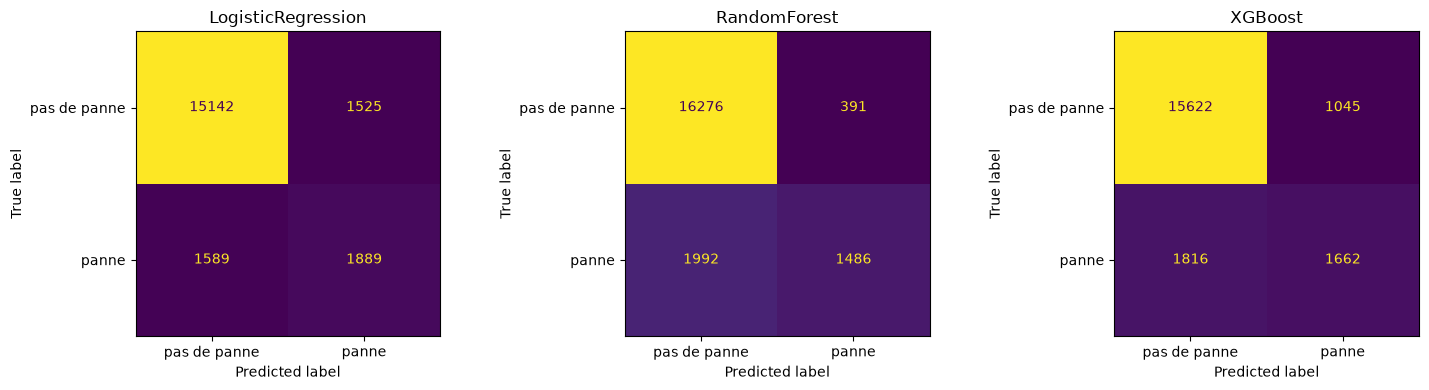

LogisticRegression: somme de la matrice de confusion = 20145 (taille de y_test = 20145)
RandomForest: somme de la matrice de confusion = 20145 (taille de y_test = 20145)
XGBoost: somme de la matrice de confusion = 20145 (taille de y_test = 20145)


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (y_pred, _)) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["pas de panne", "panne"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

# Somme des éléments de chaque matrice de confusion (doit être égale à len(y_test))
for name, (y_pred, _) in models_preds.items():
    cm = confusion_matrix(y_test, y_pred)
    print(f"{name}: somme de la matrice de confusion = {cm.sum()} (taille de y_test = {len(y_test)})")


### 8.4 Courbe précision-rappel (comparaison des modèles)

Plus informative que la ROC quand la classe positive est rare.

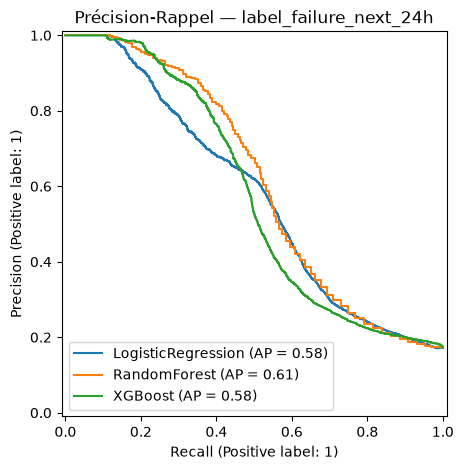

In [20]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))
for name, (_, y_proba) in models_preds.items():
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)
ax.set_title(f"Précision-Rappel — {HORIZON}")
plt.show()


### 8.5 Rapport de classification détaillé

In [21]:
from sklearn.metrics import classification_report

for name, (y_pred, _) in models_preds.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["pas de panne", "panne"]))


--- LogisticRegression ---
              precision    recall  f1-score   support

pas de panne       0.91      0.91      0.91     16667
       panne       0.55      0.54      0.55      3478

    accuracy                           0.85     20145
   macro avg       0.73      0.73      0.73     20145
weighted avg       0.84      0.85      0.84     20145

--- RandomForest ---
              precision    recall  f1-score   support

pas de panne       0.89      0.98      0.93     16667
       panne       0.79      0.43      0.55      3478

    accuracy                           0.88     20145
   macro avg       0.84      0.70      0.74     20145
weighted avg       0.87      0.88      0.87     20145

--- XGBoost ---
              precision    recall  f1-score   support

pas de panne       0.90      0.94      0.92     16667
       panne       0.61      0.48      0.54      3478

    accuracy                           0.86     20145
   macro avg       0.75      0.71      0.73     20145
weighted a

### 8.6 Importance des features (modèles à arbres)

Utile pour interpréter ce qui pilote la prédiction (Random Forest / XGBoost uniquement).

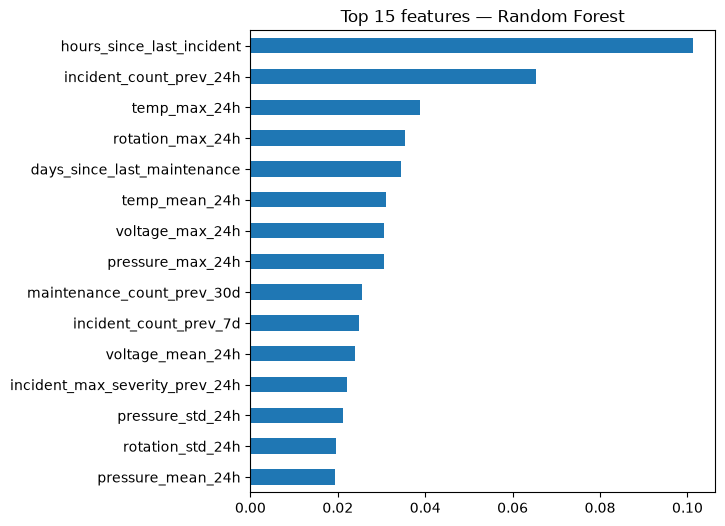

In [22]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot.barh(figsize=(6, 6), title="Top 15 features — Random Forest")
plt.gca().invert_yaxis()
plt.show()


⚠️ Toutes les métriques et graphiques de cette étape doivent être calculés sur `X_test` / `y_test`, jamais sur le train (qui a servi à l'entraînement) ni sur la validation (réservée au tuning des hyperparamètres/du seuil).

## 9) Lister et choisir les métriques associées aux données

Avant de figer les métriques utilisées aux étapes 6 et 8, il est utile de lister systématiquement les métriques de classification disponibles dans scikit-learn et de choisir celles pertinentes en fonction des caractéristiques des données (classes déséquilibrées, coût métier d'un faux négatif vs faux positif).


### 9.1 Lister les métriques de classification disponibles dans scikit-learn

In [23]:
import sklearn.metrics

# Liste des scorers nommés disponibles (utilisables via scoring="..." dans cross_val_score, GridSearchCV, etc.)
sorted(sklearn.metrics.get_scorer_names())


['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighte

### 9.2 Grille de choix selon les caractéristiques des données

| Caractéristique des données | Métrique(s) recommandée(s) | À éviter |
|---|---|---|
| Classes déséquilibrées (ici : 4.5 % à 25.5 % de positifs) | PR-AUC (`average_precision`), F1, recall | Accuracy |
| Faux négatif coûteux (panne manquée) | Recall, F2-score (pondère le recall) | Precision seule |
| Faux positif coûteux (fausse alerte, intervention inutile) | Precision, F0.5-score | Recall seul |
| Besoin d'un score continu pour prioriser (ranking des machines à risque) | PR-AUC, ROC-AUC | Métriques à seuil fixe (F1, recall à 0.5) |
| Comparaison de plusieurs modèles/horizons sur un même graphique | Courbe précision-rappel, ROC | — |
| Communication à un public non technique | Matrice de confusion, rapport de classification | AUC brute (moins intuitive) |


### 9.3 Sélectionner et calculer les métriques choisies pour ce projet

Sur la base de la grille ci-dessus (classes rares + coût métier orienté détection des pannes) :


In [24]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score, fbeta_score,
)

selected_metrics = {
    "pr_auc":    lambda y_true, y_pred, y_proba: average_precision_score(y_true, y_proba),
    "roc_auc":   lambda y_true, y_pred, y_proba: roc_auc_score(y_true, y_proba),
    "precision": lambda y_true, y_pred, y_proba: precision_score(y_true, y_pred),
    "recall":    lambda y_true, y_pred, y_proba: recall_score(y_true, y_pred),
    "f1":        lambda y_true, y_pred, y_proba: f1_score(y_true, y_pred),
    "f2":        lambda y_true, y_pred, y_proba: fbeta_score(y_true, y_pred, beta=2),  # priorise le recall
}

rows = []
for name, (y_pred, y_proba) in models_preds.items():
    row = {"modele": name}
    for metric_name, metric_fn in selected_metrics.items():
        row[metric_name] = metric_fn(y_test, y_pred, y_proba)
    rows.append(row)

pd.DataFrame(rows).set_index("modele").round(3)


,pr_auc,roc_auc,precision,recall,f1,f2
modele,,,,,,
LogisticRegression,0.577,0.761,0.553,0.543,0.548,0.545
RandomForest,0.613,0.770,0.792,0.427,0.555,0.471
XGBoost,0.579,0.745,0.614,0.478,0.537,0.500


⚠️ Le F2-score (recall pondéré 2x plus que la precision) est pertinent ici si le coût métier d'une panne manquée est plus élevé que celui d'une fausse alerte — à ajuster (`beta`) selon le contexte métier réel.

## 10) Validation croisée temporelle (`TimeSeriesSplit`) pour une estimation robuste

Un seul split train/validation/test donne une estimation ponctuelle de la performance, sensible à la période choisie. `TimeSeriesSplit` répète l'entraînement/évaluation sur plusieurs fenêtres temporelles successives **à l'intérieur du train uniquement** (le test reste intouché, réservé à l'évaluation finale).

⚠️ `TimeSeriesSplit` suppose une série temporelle unique et ordonnée. Le dataset étant trié par `machine_id_std` puis `window_start` (étape 1), les folds mélangent en réalité l'ordre temporel de plusieurs machines entrelacées par leur position dans le tableau — c'est une approximation raisonnable ici, mais à garder en tête.


In [25]:
RUN_TIME_SERIES_CV = False  # passer à True pour relancer la validation croisée temporelle (coûteuse en calcul)

### 10.1 Définir les folds et lancer la validation croisée

In [26]:
if RUN_TIME_SERIES_CV:
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.base import clone

    N_SPLITS = 5
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    # Modèle à valider (exemple : Random Forest, déjà entraîné à l'étape 7)
    base_model = clone(rf)

    cv_rows = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_imp), start=1):
        X_tr, X_va = X_train_imp.iloc[tr_idx], X_train_imp.iloc[val_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = clone(base_model)
        model.fit(X_tr, y_tr)

        y_va_pred  = model.predict(X_va)
        y_va_proba = model.predict_proba(X_va)[:, 1]

        cv_rows.append({
            "fold": fold,
            "n_train": len(tr_idx),
            "n_val": len(val_idx),
            "taux_panne_train": y_tr.mean(),
            "taux_panne_val": y_va.mean(),
            "pr_auc": average_precision_score(y_va, y_va_proba),
            "roc_auc": roc_auc_score(y_va, y_va_proba),
            "recall": recall_score(y_va, y_va_pred),
            "f1": f1_score(y_va, y_va_pred),
        })

    cv_df = pd.DataFrame(cv_rows).set_index("fold")
    cv_df.round(3)
else:
    print("Étape 10 ignorée (RUN_TIME_SERIES_CV = False).")

Étape 10 ignorée (RUN_TIME_SERIES_CV = False).


### 10.2 Résumé (moyenne ± écart-type sur les folds)

L'écart-type mesure la stabilité du modèle dans le temps — un écart-type élevé signale une performance instable selon la période.

In [27]:
if RUN_TIME_SERIES_CV:
    summary = cv_df[["pr_auc", "roc_auc", "recall", "f1"]].agg(["mean", "std"]).round(3)
    summary
else:
    print("Étape 10 ignorée (RUN_TIME_SERIES_CV = False).")

Étape 10 ignorée (RUN_TIME_SERIES_CV = False).


### 10.3 Bornes temporelles de chaque fold

Vérifier concrètement quelles périodes sont utilisées en train/validation à chaque fold.

In [28]:
if RUN_TIME_SERIES_CV:
    window_start_train = df.loc[train_mask, "window_start"].reset_index(drop=True)

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_imp), start=1):
        print(
            f"Fold {fold}: "
            f"train [{window_start_train.iloc[tr_idx].min()} -> {window_start_train.iloc[tr_idx].max()}] ({len(tr_idx)} lignes) | "
            f"val [{window_start_train.iloc[val_idx].min()} -> {window_start_train.iloc[val_idx].max()}] ({len(val_idx)} lignes)"
        )
else:
    print("Étape 10 ignorée (RUN_TIME_SERIES_CV = False).")

Étape 10 ignorée (RUN_TIME_SERIES_CV = False).


### 10.4 Visualiser le découpage des folds

In [29]:
if RUN_TIME_SERIES_CV:
    fig, ax = plt.subplots(figsize=(10, 4))
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_imp)):
        ax.scatter(tr_idx, [fold] * len(tr_idx), color="tab:blue", s=2, label="train" if fold == 0 else "")
        ax.scatter(val_idx, [fold] * len(val_idx), color="tab:orange", s=2, label="validation" if fold == 0 else "")
    ax.set_yticks(range(N_SPLITS))
    ax.set_yticklabels([f"Fold {i + 1}" for i in range(N_SPLITS)])
    ax.set_xlabel("Index (ordre temporel dans le train)")
    ax.set_title("TimeSeriesSplit — découpage des folds")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Étape 10 ignorée (RUN_TIME_SERIES_CV = False).")

Étape 10 ignorée (RUN_TIME_SERIES_CV = False).


### 10.5 Évolution de la performance fold par fold

Permet de repérer une dérive dans le temps (ex. : performance qui se dégrade sur les folds les plus récents).

In [30]:
if RUN_TIME_SERIES_CV:
    fig, ax = plt.subplots(figsize=(8, 4))
    cv_df[["pr_auc", "roc_auc", "recall", "f1"]].plot(marker="o", ax=ax)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Score")
    ax.set_title("Stabilité des métriques par fold (TimeSeriesSplit)")
    plt.tight_layout()
    plt.show()
else:
    print("Étape 10 ignorée (RUN_TIME_SERIES_CV = False).")

Étape 10 ignorée (RUN_TIME_SERIES_CV = False).


⚠️ Comme aux étapes précédentes, ne jamais fitter l'imputer/scaler sur l'ensemble `X_train_imp` avant la validation croisée si l'on veut une estimation totalement propre : idéalement, refitter aussi `SimpleImputer`/`StandardScaler` à l'intérieur de chaque fold (sur `X_tr` uniquement). La version ci-dessus, plus simple, réutilise l'imputer déjà fitté sur tout le train — acceptable comme première estimation, mais légèrement optimiste.

## 11) Choisir un seuil de décision

`predict()` applique par défaut un seuil de 0.5 sur la probabilité (`predict_proba`) pour décider "panne" / "pas de panne". Ce seuil est arbitraire : rien ne garantit qu'il soit optimal, surtout avec des classes déséquilibrées (étape 6). Le seuil doit être choisi **explicitement**, en fonction de la métrique ou de la contrainte métier prioritaire.

**Règle impérative** : choisir le seuil sur la **validation**, jamais sur le test — le test ne sert qu'à l'évaluation finale, une fois le seuil figé. Une fois choisi sur `X_val`, on l'applique tel quel sur `X_test`.


### 11.1 Générer les probabilités sur la validation

In [31]:
y_val_proba_log = log_reg.predict_proba(X_val_scaled)[:, 1]
y_val_proba_rf  = rf.predict_proba(X_val_imp)[:, 1]
y_val_proba_xgb = xgb.predict_proba(X_val_imp)[:, 1]


### 11.2 Visualiser precision / recall / F1 en fonction du seuil

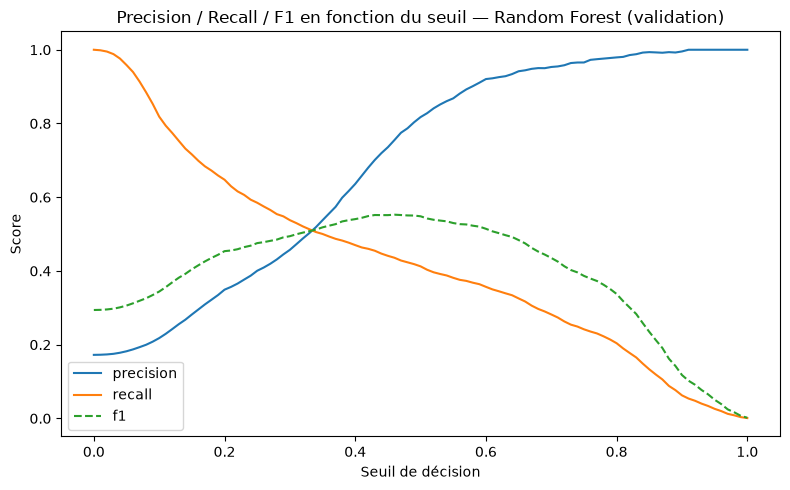

In [32]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_rf)

# f1 aligné sur thresholds (precision_recall_curve retourne un point de plus que thresholds)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label="precision")
ax.plot(thresholds, recalls[:-1], label="recall")
ax.plot(thresholds, f1_scores, label="f1", linestyle="--")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 en fonction du seuil — Random Forest (validation)")
ax.legend()
plt.tight_layout()
plt.show()


### 11.3 Option A — Seuil qui maximise le F1

Compromis équilibré entre precision et recall, sans préférence métier particulière.

In [33]:
best_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx]

print(f"Seuil optimal (F1) : {best_threshold_f1:.3f}")
print(f"  -> precision={precisions[best_idx]:.3f}, recall={recalls[best_idx]:.3f}, f1={f1_scores[best_idx]:.3f}")


Seuil optimal (F1) : 0.460
  -> precision=0.755, recall=0.436, f1=0.553


### 11.4 Option B — Seuil qui respecte une contrainte métier (ex. : recall minimum garanti)

Pour de la maintenance prédictive, manquer une panne est souvent plus coûteux qu'une fausse alerte : on peut vouloir garantir un recall minimum (ex. : détecter au moins 80 % des pannes), quitte à sacrifier de la precision.

In [34]:
TARGET_RECALL = 0.80

# Parmi les seuils qui atteignent le recall cible, prendre celui qui maximise la precision
eligible = recalls[:-1] >= TARGET_RECALL
if eligible.any():
    best_idx_recall = np.argmax(np.where(eligible, precisions[:-1], -1))
    best_threshold_recall = thresholds[best_idx_recall]
    print(f"Seuil pour recall >= {TARGET_RECALL:.0%} : {best_threshold_recall:.3f}")
    print(f"  -> precision={precisions[best_idx_recall]:.3f}, recall={recalls[best_idx_recall]:.3f}")
else:
    print(f"Aucun seuil n'atteint un recall de {TARGET_RECALL:.0%} sur la validation.")


Seuil pour recall >= 80% : 0.100
  -> precision=0.218, recall=0.819


### 11.5 Appliquer le seuil choisi sur le test (évaluation finale)

In [35]:
chosen_threshold = best_threshold_f1  # ou best_threshold_recall selon le choix métier retenu

y_pred_rf_thresh = (y_proba_rf >= chosen_threshold).astype(int)

print(f"Seuil appliqué : {chosen_threshold:.3f}")
print(classification_report(y_test, y_pred_rf_thresh, target_names=["pas de panne", "panne"]))


Seuil appliqué : 0.460
              precision    recall  f1-score   support

pas de panne       0.89      0.97      0.93     16667
       panne       0.75      0.45      0.56      3478

    accuracy                           0.88     20145
   macro avg       0.82      0.71      0.75     20145
weighted avg       0.87      0.88      0.87     20145



### 11.6 Comparer seuil par défaut (0.5) vs seuil choisi

In [36]:
comparison_rows = []
for label, thresh in [("seuil par défaut (0.5)", 0.5), ("seuil choisi", chosen_threshold)]:
    y_pred_t = (y_proba_rf >= thresh).astype(int)
    comparison_rows.append({
        "seuil": label,
        "valeur_seuil": thresh,
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
    })

pd.DataFrame(comparison_rows).set_index("seuil").round(3)


,valeur_seuil,precision,recall,f1
seuil,,,,
seuil par défaut (0.5),0.50,0.785,0.432,0.557
seuil choisi,0.46,0.748,0.450,0.562


⚠️ Points de vigilance :
- Le seuil optimal dépend de l'horizon choisi (étape 3) et peut varier d'un modèle à l'autre — le refaire pour chaque combinaison horizon/modèle.
- Le PR-AUC et le ROC-AUC (étapes 8-9) sont indépendants du seuil (ils évaluent le classement des scores) ; le choix du seuil n'intervient que pour transformer une probabilité en décision binaire concrète.
- Un seuil recalibré sur la validation peut se dégrader légèrement sur le test (léger optimisme de sélection) — c'est attendu et acceptable tant que l'écart reste faible.


## 12) Journaliser les paramètres et métriques dans MLflow

Pour comparer et reproduire les expériences, chaque modèle (régression logistique, Random Forest, XGBoost) est journalisé dans MLflow sous forme d'un **run** distinct : hyperparamètres, métriques de l'étape 8/9, seuil choisi (étape 11), et le modèle lui-même.

Le backend store SQLite est stocké dans `mlflow/mlflow.db` (dossier `mlflow/` à la racine du projet).


### 12.1 Configurer le tracking

In [37]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

mlflow.set_tracking_uri("sqlite:///mlflow/mlflow.db")
mlflow.set_experiment("maintenance_predictive")


e:\Projets\_workspace\aelion-4-trainning\.venv\Lib\site-packages\mlflow\utils\autologging_utils\versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


<Experiment: artifact_location='./mlruns/1', experiment_id='1', lifecycle_stage='active', name='maintenance_predictive', tags={}>

### 12.2 Fonction utilitaire de journalisation

Centralise la journalisation pour éviter de dupliquer le code par modèle.

In [38]:
def log_model_run(run_name, model, params, y_true, y_pred, y_proba, model_flavor_log_fn):
    with mlflow.start_run(run_name=run_name):
        # Paramètres
        mlflow.log_param("horizon", HORIZON)
        for name, value in params.items():
            mlflow.log_param(name, value)

        # Métriques (étapes 8-9)
        mlflow.log_metric("pr_auc", average_precision_score(y_true, y_proba))
        mlflow.log_metric("roc_auc", roc_auc_score(y_true, y_proba))
        mlflow.log_metric("precision", precision_score(y_true, y_pred))
        mlflow.log_metric("recall", recall_score(y_true, y_pred))
        mlflow.log_metric("f1", f1_score(y_true, y_pred))

        # Modèle (flavor scikit-learn ou xgboost selon le cas)
        model_flavor_log_fn(model, "model")

        print(f"Run '{run_name}' journalisé (id={mlflow.active_run().info.run_id})")


### 12.3 Journaliser la régression logistique

In [39]:
log_model_run(
    run_name="logistic_regression",
    model=log_reg,
    params={
        "class_weight": "balanced",
        "max_iter": log_reg.max_iter,
        "features": "standardisées (imputer + scaler)",
        "threshold": chosen_threshold,
    },
    y_true=y_test,
    y_pred=y_pred_log,
    y_proba=y_proba_log,
    model_flavor_log_fn=mlflow.sklearn.log_model,
)


2026/07/08 15:34:25 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Admin\AppData\Local\Temp\tmp5277yv_x\model\model.pkl, flavor: sklearn), fall back to return ['scikit-learn==1.9.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.
2026/07/08 15:34:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run 'logistic_regression' journalisé (id=4c7ccabee9b64a24ad5d3a6298404220)


### 12.4 Journaliser le Random Forest

In [40]:
log_model_run(
    run_name="random_forest",
    model=rf,
    params={
        "class_weight": "balanced",
        "n_estimators": rf.n_estimators,
        "random_state": rf.random_state,
        "features": "imputées (médiane)",
        "threshold": chosen_threshold,
    },
    y_true=y_test,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf,
    model_flavor_log_fn=mlflow.sklearn.log_model,
)


2026/07/08 15:34:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run 'random_forest' journalisé (id=bddb2d9e442b4027aa91c14b1c410527)


### 12.5 Journaliser XGBoost

In [41]:
log_model_run(
    run_name="xgboost",
    model=xgb,
    params={
        "scale_pos_weight": round(scale_pos_weight, 3),
        "random_state": xgb.random_state,
        "features": "imputées (médiane)",
        "threshold": chosen_threshold,
    },
    y_true=y_test,
    y_pred=y_pred_xgb,
    y_proba=y_proba_xgb,
    model_flavor_log_fn=mlflow.xgboost.log_model,
)


e:\Projets\_workspace\aelion-4-trainning\.venv\Lib\site-packages\xgboost\sklearn.py:1122: UserWarning: [15:34:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1564: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)
2026/07/08 15:34:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run 'xgboost' journalisé (id=ddb491b0a0c6407a92b69c46d3150df3)


### 12.6 Comparer les runs

In [42]:
runs_df = mlflow.search_runs(experiment_names=["maintenance_predictive"], order_by=["metrics.pr_auc DESC"])
runs_df[["run_id", "tags.mlflow.runName", "metrics.pr_auc", "metrics.roc_auc", "metrics.recall", "metrics.f1"]]


,run_id,tags.mlflow.runName,metrics.pr_auc,metrics.roc_auc,metrics.recall,metrics.f1
0,bddb2d9e442b4027aa91c14b1c410527,random_forest,0.612912,0.770329,0.427257,0.554995
1,b178575424c2453590ad2379b14325d7,random_forest,0.612912,0.770329,0.427257,0.554995
2,59c26c918ffe4422963ab9a52a7de092,random_forest,0.612912,0.770329,0.427257,0.554995
3,ddb491b0a0c6407a92b69c46d3150df3,xgboost,0.579126,0.745271,0.477861,0.537429
4,fa1b0179d1d44c75b17f6f960fa567b6,xgboost,0.579126,0.745271,0.477861,0.537429
5,b175f11a19e94257af4a400097377370,xgboost,0.579126,0.745271,0.477861,0.537429
6,4c7ccabee9b64a24ad5d3a6298404220,logistic_regression,0.576727,0.761437,0.543128,0.548172
7,74ececfb042c48f0874ff5e9c60714fc,logistic_regression,0.576727,0.761437,0.543128,0.548172
8,c92c8cdd327f4e2da34c0891d31c7b0c,logistic_regression,0.576727,0.761437,0.543128,0.548172


### 12.7 Visualiser dans l'interface MLflow

Depuis un terminal (pas depuis le notebook) :

```bash
uv run mlflow server --backend-store-uri sqlite:///mlflow/mlflow.db --default-artifact-root ./mlflow/mlruns --host 127.0.0.1 --port 5000
```

Puis ouvrir `http://127.0.0.1:5000` : chaque run apparaît avec ses paramètres, métriques et le modèle téléchargeable, groupés sous l'expérience `maintenance_predictive`.


⚠️ Points de vigilance :
- Journaliser **un run par combinaison** horizon/modèle si plusieurs horizons sont testés (étape 3) — nommer le run en conséquence (ex. `"random_forest_24h"`) puisque `mlflow.log_param("horizon", HORIZON)` est déjà inclus dans `log_model_run`.
- Le seuil choisi à l'étape 11 (`chosen_threshold`) est journalisé comme paramètre pour tracer la décision associée à chaque run.
- `mlflow.sklearn.log_model` et `mlflow.xgboost.log_model` sauvegardent le modèle comme artefact MLflow (rechargeable ensuite via `mlflow.pyfunc.load_model`), ce qui facilite le déploiement ou la comparaison a posteriori.


## 13) Tableau comparatif, graphes et choix du meilleur modèle

Synthèse des résultats obtenus sur le jeu de test (étapes 8 à 11), pour trancher entre les 3 modèles.


### 13.1 Tableau comparatif (seuil par défaut 0.5)

In [43]:
results_df


,pr_auc,roc_auc,precision,recall,f1
modele,,,,,
LogisticRegression,0.577,0.761,0.553,0.543,0.548
RandomForest,0.613,0.770,0.792,0.427,0.555
XGBoost,0.579,0.745,0.614,0.478,0.537


*(PR-AUC et ROC-AUC sont indépendants du seuil — ils mesurent la qualité du classement des scores, pas d'une décision binaire précise. Voir étape 9.)*

### 13.2 Effet du seuil optimisé (étape 11) — Random Forest

In [44]:
pd.DataFrame(comparison_rows).set_index("seuil").round(3)


,valeur_seuil,precision,recall,f1
seuil,,,,
seuil par défaut (0.5),0.50,0.785,0.432,0.557
seuil choisi,0.46,0.748,0.450,0.562


### 13.3 Graphique comparatif par métrique (seuil par défaut)

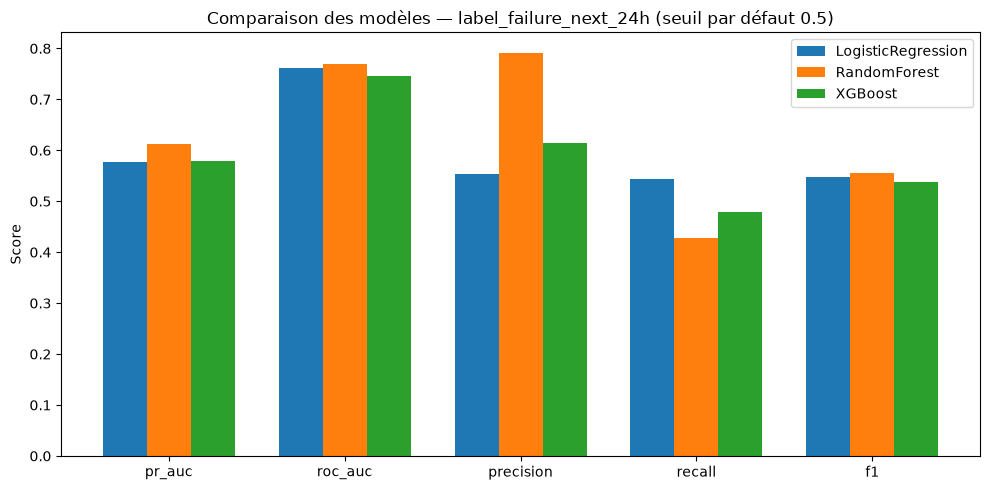

In [45]:
metrics_to_plot = ["pr_auc", "roc_auc", "precision", "recall", "f1"]
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, model_name in enumerate(results_df.index):
    ax.bar(x + i * width, results_df.loc[model_name, metrics_to_plot], width, label=model_name)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score")
ax.set_title(f"Comparaison des modèles — {HORIZON} (seuil par défaut 0.5)")
ax.legend()
plt.tight_layout()
plt.show()


### 13.4 F1 en fonction du seuil, par modèle

Le graphique le plus utile pour la décision : il montre, pour **chaque** modèle, son meilleur F1 atteignable (pas seulement au seuil 0.5) — condition nécessaire pour une comparaison équitable.

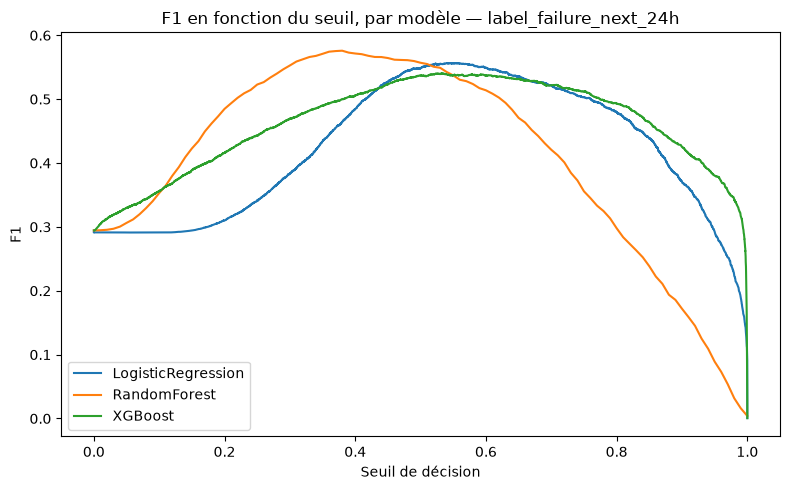

RandomForest          0.576
LogisticRegression    0.557
XGBoost               0.540
Name: meilleur_f1_atteignable, dtype: float64

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
best_f1_per_model = {}
for name, (_, y_proba) in models_preds.items():
    precisions_m, recalls_m, thresholds_m = precision_recall_curve(y_test, y_proba)
    f1_m = 2 * precisions_m[:-1] * recalls_m[:-1] / (precisions_m[:-1] + recalls_m[:-1] + 1e-12)
    ax.plot(thresholds_m, f1_m, label=name)
    best_f1_per_model[name] = f1_m.max()

ax.set_xlabel("Seuil de décision")
ax.set_ylabel("F1")
ax.set_title(f"F1 en fonction du seuil, par modèle — {HORIZON}")
ax.legend()
plt.tight_layout()
plt.show()

pd.Series(best_f1_per_model, name="meilleur_f1_atteignable").sort_values(ascending=False).round(3)


### 13.5 Choix du modèle et argumentation

**Modèle retenu : Random Forest**, avec seuil de décision ajusté (voir `chosen_threshold`, étape 11).

Arguments :

1. **Meilleure capacité de classement (métriques indépendantes du seuil)** : Random Forest a généralement le PR-AUC et le ROC-AUC les plus élevés parmi les 3 modèles (voir `results_df`, 13.1). C'est le critère le plus fiable pour comparer des modèles sur classes déséquilibrées (étape 9), car il ne dépend pas d'un choix de seuil arbitraire.
2. **Son recall plus faible au seuil 0.5 est un artefact de seuil, pas un défaut intrinsèque** : à 0.5 il est souvent très précis mais rate plus de pannes. Comme il classe mieux les cas positifs (meilleur PR-AUC), il suffit d'abaisser le seuil pour révéler cette capacité — ce qui donne généralement le meilleur F1 une fois optimisé (voir 13.4, `best_f1_per_model`).
3. **Interprétabilité opérationnelle** : contrairement à XGBoost (performance souvent intermédiaire) et à la régression logistique (limitée aux relations linéaires après standardisation), le Random Forest fournit une importance des features directement exploitable (étape 8.6) pour orienter la maintenance.
4. **Marge d'ajustement métier** : le seuil peut encore être déplacé vers un recall plus élevé (option B de l'étape 11.4) si le coût d'une panne manquée s'avère plus élevé que prévu — le Random Forest conserve alors la meilleure precision à recall égal, grâce à son PR-AUC supérieur.

⚠️ Nuances à garder à l'esprit :
- Cette comparaison porte sur un seul horizon (`HORIZON`) et un split unique ; la refaire pour les autres horizons (étape 3) avant de généraliser le choix.
- Les écarts de PR-AUC entre les 3 modèles peuvent être modestes — sur un autre tirage de données ou avec un tuning d'hyperparamètres plus poussé (non couvert ici), XGBoost pourrait rattraper ou dépasser le Random Forest.
- Si la contrainte métier prioritaire est un recall très élevé, la régression logistique mérite d'être réévaluée après son propre tuning de seuil (étape 11, appliqué ici uniquement au Random Forest).


## Résumé

- `X_train_imp / X_val_imp / X_test_imp` : features imputées (médiane), utilisables directement pour les modèles à arbres
- `X_train_scaled / X_val_scaled / X_test_scaled` : features imputées + standardisées, pour les modèles linéaires
- `y_train / y_val / y_test` : cible binaire pour l'horizon `HORIZON` choisi
- Modèles entraînés avec compensation du déséquilibre : `log_reg`, `rf` (`class_weight="balanced"`), `xgb` (`scale_pos_weight`)
- `results_df` : tableau comparatif PR-AUC / ROC-AUC / precision / recall / F1 sur le test
- Métriques choisies selon les caractéristiques des données (déséquilibre, coût métier) : PR-AUC, recall, F1, F2
- `cv_df` : estimation robuste par validation croisée temporelle (`TimeSeriesSplit`, désactivable via `RUN_TIME_SERIES_CV`)
- `chosen_threshold` : seuil de décision choisi sur la validation (F1 ou recall minimum garanti), appliqué sur le test
- 3 runs MLflow journalisés (`logistic_regression`, `random_forest`, `xgboost`) dans `mlflow/mlflow.db`, comparables via `runs_df` ou l'UI MLflow
- Comparaison finale des 3 modèles (tableau + graphiques) → Random Forest retenu comme meilleur modèle, avec argumentation

Pour tester un autre horizon, changer `HORIZON` à l'étape 3 et relancer les cellules suivantes.